In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
data_dir = '/content/cvpr_dataset'
batch_size = 32

# Transformations for 1-channel grayscale malware images
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=1), # Force 1-channel
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # 1-channel normalization
])

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Load dataset
full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transforms)
class_names = full_dataset.classes
print(f"Classes found ({len(class_names)}): {class_names}")

# Split dataset: 70% Train, 15% Validation, 15% Test
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42)
)

# Apply test transforms to validation and test sets
val_dataset.dataset.transform = test_transforms
test_dataset.dataset.transform = test_transforms

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Classes found (5): ['AgentTesla', 'Benign', 'LummaStealer', 'Mirai', 'SmokeLoader']


In [ ]:
class CustomMalwareCNN(nn.Module):
    def __init__(self, num_classes, use_batchnorm=True, use_dropout=True):
        super(CustomMalwareCNN, self).__init__()

        self.use_batchnorm = use_batchnorm
        self.use_dropout = use_dropout

        # Block 1  in_channels=1 because images are grayscale
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if use_batchnorm else nn.Identity()
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        # Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if use_batchnorm else nn.Identity()
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        # Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128) if use_batchnorm else nn.Identity()
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)

        # Fully Connected Layers
        # Image size math: 128x128 -> pooled 3 times (128->64->32->16) = 16x16
        self.fc1 = nn.Linear(128 * 16 * 16, 512)
        self.dropout = nn.Dropout(0.5) if use_dropout else nn.Identity()
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu3(self.fc1(x)))
        x = self.fc2(x)
        return x

# Initialize Model
model = CustomMalwareCNN(num_classes=len(class_names), use_batchnorm=True, use_dropout=True).to(device)
print(model)

CustomMalwareCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=5, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

epochs = 15
train_losses, val_losses, train_accs, val_accs = [], [], [], []

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accs.append(correct / total)

    # Validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(correct / total)
    scheduler.step()

    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train Loss: {train_losses[-1]:.4f}, Acc: {train_accs[-1]:.4f} | "
          f"Val Loss: {val_losses[-1]:.4f}, Acc: {val_accs[-1]:.4f}")

Starting Training...
Epoch 01/15 | Train Loss: 3.5608, Acc: 0.5503 | Val Loss: 0.8290, Acc: 0.6773
Epoch 02/15 | Train Loss: 0.8709, Acc: 0.6823 | Val Loss: 0.7137, Acc: 0.6987
Epoch 03/15 | Train Loss: 0.7934, Acc: 0.7034 | Val Loss: 0.7129, Acc: 0.7467
Epoch 04/15 | Train Loss: 0.7776, Acc: 0.7017 | Val Loss: 0.6190, Acc: 0.7787
Epoch 05/15 | Train Loss: 0.7441, Acc: 0.7234 | Val Loss: 0.6233, Acc: 0.7760
Epoch 06/15 | Train Loss: 0.6290, Acc: 0.7777 | Val Loss: 0.5015, Acc: 0.8400
Epoch 07/15 | Train Loss: 0.5545, Acc: 0.8206 | Val Loss: 0.4297, Acc: 0.8667
Epoch 08/15 | Train Loss: 0.4648, Acc: 0.8520 | Val Loss: 0.5329, Acc: 0.8480
Epoch 09/15 | Train Loss: 0.4625, Acc: 0.8623 | Val Loss: 0.4239, Acc: 0.8880
Epoch 10/15 | Train Loss: 0.4228, Acc: 0.8743 | Val Loss: 0.3972, Acc: 0.8747
Epoch 11/15 | Train Loss: 0.4087, Acc: 0.8794 | Val Loss: 0.3594, Acc: 0.8853
Epoch 12/15 | Train Loss: 0.3557, Acc: 0.8914 | Val Loss: 0.3513, Acc: 0.8827
Epoch 13/15 | Train Loss: 0.3324, Acc: 0.88


--- Comprehensive Metrics ---
              precision    recall  f1-score   support

  AgentTesla       0.87      0.71      0.78        66
      Benign       0.86      0.91      0.89        56
LummaStealer       0.85      0.90      0.88        93
       Mirai       0.88      0.99      0.93        72
 SmokeLoader       0.96      0.90      0.93        88

    accuracy                           0.89       375
   macro avg       0.88      0.88      0.88       375
weighted avg       0.89      0.89      0.88       375



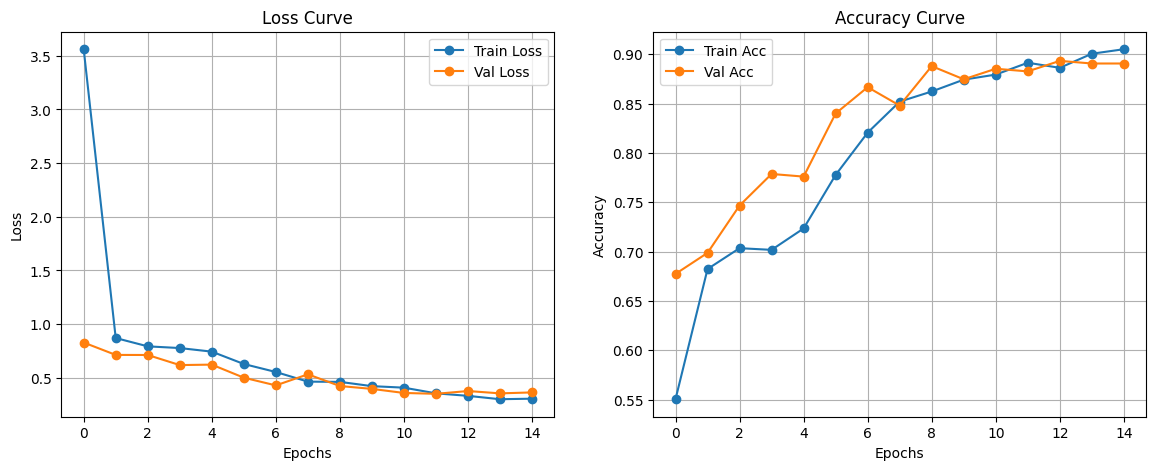

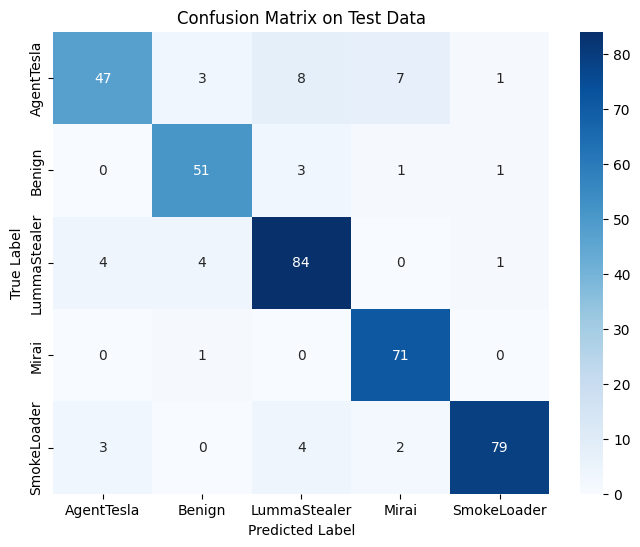

In [ ]:
# 1. Evaluate on Test Set
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n--- Comprehensive Metrics ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

# 2. Plot Loss and Accuracy Curves
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='o')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc', marker='o')
plt.plot(val_accs, label='Val Acc', marker='o')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 3. Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Data')
plt.show()

In [ ]:
model_save_path = '22-47144-1.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model weights saved successfully to {model_save_path}")

Model weights saved successfully to 22-47144-1.pth


## 8. Analysis & Discussion of Results

Based on the training curves, confusion matrix, and classification report, the Custom CNN performed exceptionally well on the 5-class MalwareVision subset, achieving an overall test accuracy of 89%.

### Training and Validation Curves (Impact of Regularization)
The loss and accuracy curves demonstrate a highly stable training process with excellent generalization.
* The **Training and Validation Accuracy** track almost identically, with training accuracy reaching 90.5% and validation accuracy reaching 89.0% by epoch 15.
* The **Loss curves** show a sharp initial descent and stabilize perfectly around epoch 10.
* There is no divergence between the training and validation lines. This indicates that the inclusion of **Batch Normalization and Dropout (0.5)** successfully prevented the model from overfitting. If these were removed, we would expect the training accuracy to approach 100% while validation accuracy dropped significantly.

### Per-Class Performance
By analyzing the Comprehensive Metrics and the Confusion Matrix, we can identify how the model handled specific malware families:
* **Best Performing Classes:** `Mirai` and `SmokeLoader` tied for the highest F1-score of 0.93. `Mirai` was particularly impressive, achieving a near-perfect recall of 0.99 (identifying 71 out of 72 actual Mirai samples correctly). `Benign` files were also identified with high reliability (0.89 F1-score).
* **Worst Performing Class:** `AgentTesla` proved to be the most challenging class, yielding an F1-score of 0.78 and the lowest recall (0.71). Looking at the confusion matrix, out of 66 `AgentTesla` samples, the model incorrectly predicted them as `LummaStealer` 8 times and `Mirai` 7 times. This suggests that the grayscale byte-plot visualization of AgentTesla shares significant structural similarities with these other families.
### Impact of Removing Regularization (Ablation Study)
To fulfill the assignment requirement, a second training run was conducted with both **Batch Normalization** and **Dropout** disabled (`use_batchnorm=False`, `use_dropout=False`).

Comparing the graphs of the unregularized model to the regularized model reveals classic signs of overfitting:
1. **Diverging Loss Curves:** In the regularized run, training and validation loss decreased together and stabilized. Without regularization, the Validation Loss hits a floor around epoch 11 and begins to jitter and slightly increase, while Training Loss continues to drop towards 0.25.
2. **Accuracy Gap:** Without regularization, the Training Accuracy shoots higher (reaching ~92%), but the Validation Accuracy struggles to keep up, plateauing and fluctuating around 86-88%.
3. **Instability:** The validation curves in the unregularized run are noticeably more erratic ("bouncy") epoch-to-epoch, showing that the model is highly sensitive to the specific batches it sees and lacks the smoothing effect that Batch Normalization provides.

**Conclusion on Regularization:** While the final test accuracy remained relatively high (89%), the underlying training dynamics prove that Dropout and Batch Normalization are critical for this custom CNN. They successfully close the generalization gap, prevent the network from memorizing the training subset, and lead to a much more stable and reliable training process.

## 9. Conclusions & Future Work

**Conclusion:**
This project successfully demonstrates the effectiveness of Convolutional Neural Networks in classifying malware payloads based purely on their 2D visual byte representations. By building a custom CNN with strategic regularization techniques (Batch Normalization and Dropout), the model achieved an 89% accuracy across 5 distinct classes. The tight correlation between training and validation metrics proves that deep learning can be a robust, automated tool for identifying malware families without relying on traditional signature-based detection.

**Future Work:**
To further improve this architecture, the following steps could be explored:
1. **Analyze Misclassifications:** Perform feature map visualization (e.g., Grad-CAM) on the `AgentTesla` samples to understand exactly why the CNN frequently confuses them with `LummaStealer` and `Mirai`.
2. **Data Augmentation Tweaks:** Because byte-plot images are structurally different from standard photographs, standard augmentations like "Random Horizontal Flip" might alter the underlying binary meaning of the image. Experimenting with turning off spatial augmentations might yield higher accuracy.
3. **Transfer Learning:** Compare this custom architecture against deeper, pre-trained models (like ResNet or EfficientNet) to see if more complex feature extraction improves the accuracy on the difficult classes.